# 3A

##Penjelasan Cara Kerja Arsitektur Generative Adversarial Network (GAN)

Generative Adversarial Network (GAN) merupakan salah satu arsitektur dalam deep learning yang digunakan untuk menghasilkan data baru yang menyerupai data asli. GAN terdiri dari dua jaringan saraf yang saling berkompetisi (adversarial), yaitu Generator dan Discriminator. Kedua jaringan ini dilatih secara bersamaan sehingga kemampuan masing-masing jaringan terus meningkat selama proses training.

Berdasarkan gambar arsitektur di atas, proses kerja GAN dapat dijelaskan sebagai berikut.

##Random Noise sebagai Input Generator

Proses dimulai dengan memberikan random noise atau vektor acak sebagai input ke dalam Generator. Random noise ini tidak memiliki informasi khusus, namun menjadi dasar bagi Generator untuk membentuk citra baru.

##Generator Membuat Citra Sintetis (Fake Image)

Generator memproses random noise menggunakan beberapa layer neural network sehingga menghasilkan sebuah gambar baru (fake image). Tujuan Generator adalah membuat gambar yang semirip mungkin dengan gambar asli pada dataset sehingga sulit dibedakan oleh Discriminator.

##Training Set Menyediakan Gambar Asli

Selain gambar hasil Generator, Discriminator juga menerima gambar asli (real image) yang berasal dari dataset pelatihan (training set). Dengan demikian, Discriminator memperoleh dua jenis data, yaitu gambar asli dan gambar buatan Generator.

##Discriminator Membedakan Real dan Fake

Discriminator berfungsi sebagai classifier biner yang menentukan apakah suatu gambar merupakan gambar asli (Real) atau gambar buatan (Fake). Discriminator akan memberikan probabilitas terhadap setiap gambar yang diterimanya.

##Perhitungan Error dan Pembaruan Bobot

Setelah Discriminator melakukan klasifikasi, nilai error dihitung menggunakan fungsi loss. Error tersebut kemudian digunakan melalui proses backpropagation untuk memperbarui bobot kedua jaringan. Discriminator dilatih agar semakin akurat dalam membedakan gambar asli dan palsu, sedangkan Generator dilatih agar mampu menghasilkan gambar yang semakin realistis sehingga dapat "menipu" Discriminator.

##Proses Berulang Hingga Model Konvergen

Langkah-langkah tersebut dilakukan secara berulang selama banyak epoch. Seiring bertambahnya proses pelatihan, kemampuan Generator menghasilkan gambar akan semakin baik, sementara Discriminator juga semakin pintar dalam melakukan klasifikasi. Pada kondisi ideal, Generator mampu menghasilkan gambar yang kualitasnya sangat mirip dengan data asli sehingga Discriminator kesulitan membedakan keduanya dan hanya dapat menebak dengan probabilitas sekitar 50%.

# 3B

In [ ]:
import os
import cv2
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
import os

print("File ada:", os.path.exists("archive.zip"))

if os.path.exists("archive.zip"):
    print("Ukuran:", os.path.getsize("archive.zip") / (1024**2), "MB")

File ada: True
Ukuran: 250.79240798950195 MB


In [ ]:
!file archive.zip

archive.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [ ]:
 import os

size = os.path.getsize("archive.zip")
print(f"{size / (1024**2):.2f} MB")

250.79 MB


In [ ]:
import zipfile

print(zipfile.is_zipfile("archive.zip"))

True


In [ ]:
import zipfile

zip_path = "archive.zip"
extract_path = "archive"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzip selesai")

Unzip selesai


In [ ]:
from pathlib import Path
import pandas as pd

DATASET_DIR = Path("/content/archive/archive/version2")

classes = ["ship", "helicopter"]

image_paths = []
labels = []

for split in ["train", "test"]:
    for cls in classes:
        folder = DATASET_DIR / split / cls

        print(f"{split}/{cls}:", folder.exists(), "->", len(list(folder.glob("*.jpg"))) if folder.exists() else 0)

        for img_path in folder.glob("*.jpg"):
            image_paths.append(str(img_path))
            labels.append(cls)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("\nTotal data:", len(df))
print("\nJumlah per kelas:")
print(df["label"].value_counts())

display(df.head())

train/ship: True -> 7124
train/helicopter: True -> 5250
test/ship: True -> 888
test/helicopter: True -> 656

Total data: 13918

Jumlah per kelas:
label
ship          8012
helicopter    5906
Name: count, dtype: int64


,filepath,label
0,/content/archive/archive/version2/train/ship/0...,ship
1,/content/archive/archive/version2/train/ship/0...,ship
2,/content/archive/archive/version2/train/ship/2...,ship
3,/content/archive/archive/version2/train/ship/1...,ship
4,/content/archive/archive/version2/train/ship/2...,ship


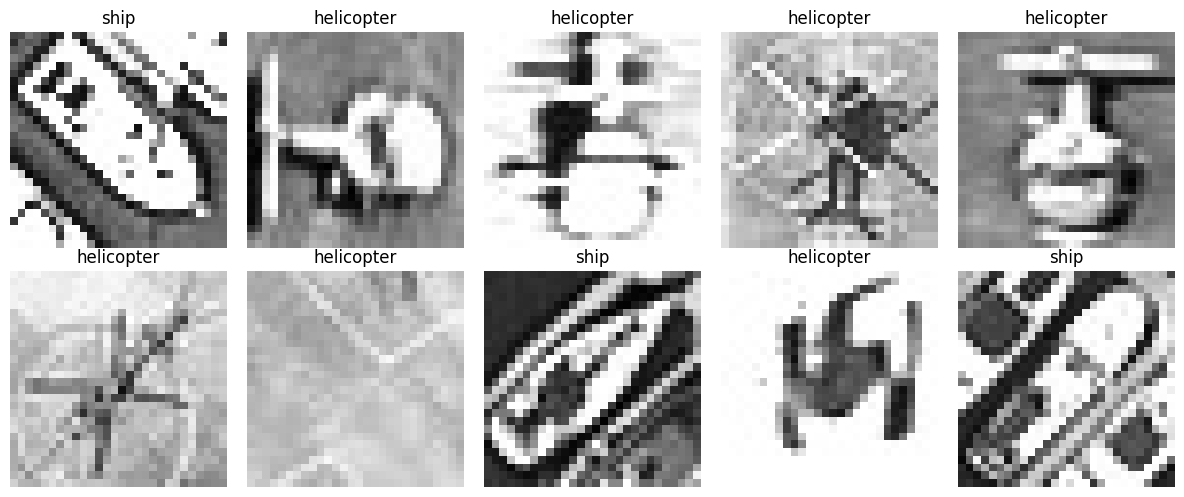

In [ ]:
# Visualisasi dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, (_, row) in zip(axes.flatten(), df.sample(10, random_state=42).iterrows()):

    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Preprocessing data
IMG_SIZE = 28

images = []
labels = []

for _, row in df.iterrows():

    img = cv2.imread(row["filepath"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    images.append(img)

    labels.append(row["label"])

X = np.array(images, dtype=np.float32)

y = np.array(labels)

print("Image Shape :", X.shape)
print("Label Shape :", y.shape)

Image Shape : (13918, 28, 28, 3)
Label Shape : (13918,)


In [ ]:
# Encode label
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)
print(np.unique(y))

['helicopter' 'ship']
[0 1]


In [ ]:
# Normalize
X = (X - 127.5) / 127.5

print(X.min(), X.max())

-1.0 1.0


In [ ]:
from sklearn.model_selection import train_test_split

# 80% Train | 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 20% Temporary -> 10% Validation | 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set    :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set    :", X_test.shape)

Training Set    : (11134, 28, 28, 3)
Validation Set : (1392, 28, 28, 3)
Testing Set    : (1392, 28, 28, 3)


# GAN LAYER

In [ ]:
# Parameter model GAN
LATENT_DIM = 100

NUM_CLASSES = len(np.unique(y_train))

IMG_SHAPE = X_train.shape[1:]

EPOCHS = 300

BATCH_SIZE = 64

LEARNING_RATE = 0.0002

In [ ]:
# iMport GAN Layer
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Embedding,
    Concatenate,
    Reshape,
    BatchNormalization,
    LeakyReLU,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

## Generator

In [ ]:
# Generator
def build_generator():

    noise = Input(shape=(LATENT_DIM,), name="Noise")

    label = Input(shape=(1,), dtype="int32", name="Label")

    label_embedding = Embedding(NUM_CLASSES, 50)(label)
    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([noise, label_embedding])

    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(1024)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(int(np.prod(IMG_SHAPE)), activation="tanh")(x)

    output = Reshape(IMG_SHAPE)(x)

    return Model([noise, label], output, name="Generator")

In [ ]:
generator = build_generator()

generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        100 │ Label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ Noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     19,328 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2352)      │  2,410,800 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 3) │          0 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,127,828 (11.93 MB)

 Trainable params: 3,123,988 (11.92 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
# Discriminator
def build_discriminator():

    image = Input(shape=IMG_SHAPE, name="Image")

    label = Input(shape=(1,), dtype="int32", name="Label")

    label_embedding = Embedding(NUM_CLASSES, 50)(label)
    label_embedding = Flatten()(label_embedding)

    image_flat = Flatten()(image)

    x = Concatenate()([image_flat, label_embedding])

    x = Dense(1024)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(512)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(256)(x)
    x = LeakyReLU(0.2)(x)

    output = Dense(1, activation="sigmoid")(x)

    return Model([image, label], output, name="Discriminator")

In [ ]:
discriminator = build_discriminator()

discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Image (InputLayer)  │ (None, 28, 28, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        100 │ Label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2352)      │          0 │ Image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2402)      │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1024)      │  2,460,672 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 1024)      │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 512)       │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 256)       │          0 │ dense_7[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        257 │ leaky_re_lu_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,117,157 (11.89 MB)

 Trainable params: 3,117,157 (11.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile Discriminator
optimizer_d = Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator.compile(
    optimizer=optimizer_d,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Build Conditional GAN
# Bekukan discriminator hanya saat membuat GAN
discriminator.trainable = False

noise = Input(shape=(LATENT_DIM,))
label = Input(shape=(1,), dtype="int32")

generated_image = generator([noise, label])

validity = discriminator([generated_image, label])

gan = Model(
    [noise, label],
    validity,
    name="Conditional_GAN"
)

optimizer_g = Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

gan.compile(
    optimizer=optimizer_g,
    loss="binary_crossentropy"
)

# Aktifkan kembali discriminator untuk training berikutnya
discriminator.trainable = True

In [ ]:
# Label untuk Training
real = np.ones((BATCH_SIZE, 1), dtype=np.float32)
fake = np.zeros((BATCH_SIZE, 1), dtype=np.float32)

In [ ]:
# Training LOop
g_losses = []
d_losses = []

for epoch in range(EPOCHS):

    # Train Discriminator
    discriminator.trainable = True

    idx = np.random.randint(
        0,
        X_train.shape[0],
        BATCH_SIZE
    )

    real_images = X_train[idx]

    real_labels = y_train[idx].reshape(-1,1)

    noise = np.random.normal(
        0,
        1,
        (BATCH_SIZE,LATENT_DIM)
    )

    fake_images = generator.predict(
        [noise,real_labels],
        verbose=0
    )

    real_target = np.ones((BATCH_SIZE,1))

    fake_target = np.zeros((BATCH_SIZE,1))

    d_loss_real = discriminator.train_on_batch(
        [real_images,real_labels],
        real_target
    )

    d_loss_fake = discriminator.train_on_batch(
        [fake_images,real_labels],
        fake_target
    )

    d_loss = 0.5*np.add(
        d_loss_real,
        d_loss_fake
    )


    # Train Generator
    discriminator.trainable = False

    noise = np.random.normal(
        0,
        1,
        (BATCH_SIZE,LATENT_DIM)
    )

    sampled_labels = np.random.randint(
        0,
        NUM_CLASSES,
        BATCH_SIZE
    ).reshape(-1,1)

    valid_target = np.ones((BATCH_SIZE,1))

    g_loss = gan.train_on_batch(
        [noise,sampled_labels],
        valid_target
    )

    discriminator.trainable = True

    d_losses.append(float(d_loss[0]))
    g_losses.append(float(g_loss))

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {100*d_loss[1]:.2f}% | "
            f"G Loss: {g_loss:.4f}"
        )

Epoch 1/300 | D Loss: 0.6695 | D Acc: 48.05% | G Loss: 0.5060
Epoch 11/300 | D Loss: 0.3510 | D Acc: 82.19% | G Loss: 0.1724
Epoch 21/300 | D Loss: 0.3715 | D Acc: 77.20% | G Loss: 0.8572
Epoch 31/300 | D Loss: 0.3357 | D Acc: 83.66% | G Loss: 2.6275
Epoch 41/300 | D Loss: 0.2953 | D Acc: 87.12% | G Loss: 3.9709
Epoch 51/300 | D Loss: 0.2625 | D Acc: 89.19% | G Loss: 5.0731
Epoch 61/300 | D Loss: 0.2410 | D Acc: 90.41% | G Loss: 5.9110
Epoch 71/300 | D Loss: 0.2231 | D Acc: 91.29% | G Loss: 6.5432
Epoch 81/300 | D Loss: 0.2207 | D Acc: 91.45% | G Loss: 7.4100
Epoch 91/300 | D Loss: 0.2327 | D Acc: 91.54% | G Loss: 7.6567
Epoch 101/300 | D Loss: 0.2448 | D Acc: 91.37% | G Loss: 7.7275
Epoch 111/300 | D Loss: 0.2521 | D Acc: 91.32% | G Loss: 7.4530
Epoch 121/300 | D Loss: 0.2418 | D Acc: 91.77% | G Loss: 7.1151
Epoch 131/300 | D Loss: 0.2424 | D Acc: 91.79% | G Loss: 6.8186
Epoch 141/300 | D Loss: 0.2418 | D Acc: 91.80% | G Loss: 6.5237
Epoch 151/300 | D Loss: 0.2453 | D Acc: 91.68% | G 

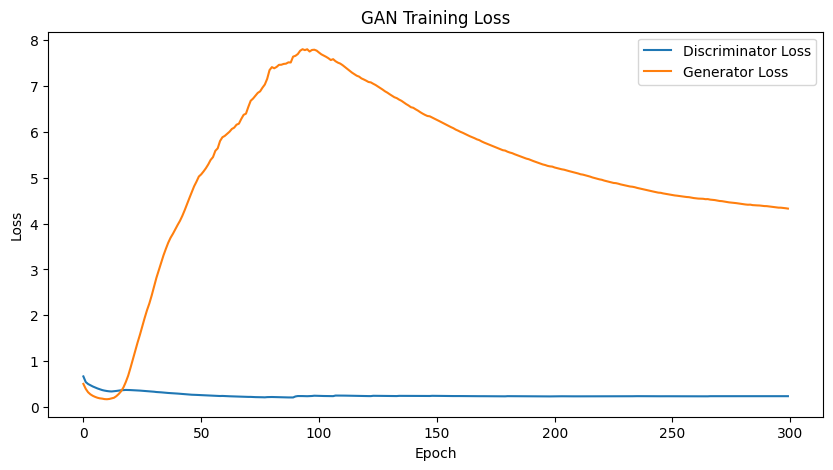

In [ ]:
# Plot Training loss
plt.figure(figsize=(10,5))

plt.plot(
    d_losses,
    label="Discriminator Loss"
)

plt.plot(
    g_losses,
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("GAN Training Loss")

plt.legend()

plt.show()

Grafik menunjukkan perkembangan Discriminator Loss (garis biru) dan Generator Loss (garis oranye) selama proses training GAN. Discriminator loss cenderung menurun dan kemudian stabil pada nilai yang rendah, menunjukkan bahwa discriminator mampu membedakan gambar asli dan gambar hasil generator secara konsisten. Sementara itu, generator loss meningkat pada awal pelatihan, mencapai puncak sekitar epoch ke-100, kemudian menurun secara bertahap hingga akhir training. Hal ini menunjukkan bahwa generator terus memperbaiki kemampuannya dalam menghasilkan gambar yang semakin menyerupai data asli. Secara keseluruhan, kedua kurva menunjukkan proses pelatihan yang berlangsung stabil tanpa indikasi divergensi yang signifikan.

In [ ]:
# Generate Image
noise = np.random.normal(
    0,
    1,
    (10, LATENT_DIM)
)

labels = np.array(
    [0,1,0,1,0,1,0,1,0,1]
).reshape(-1,1)

generated_images = generator.predict(
    [noise, labels],
    verbose=0
)

generated_images = (
    generated_images + 1
)/2

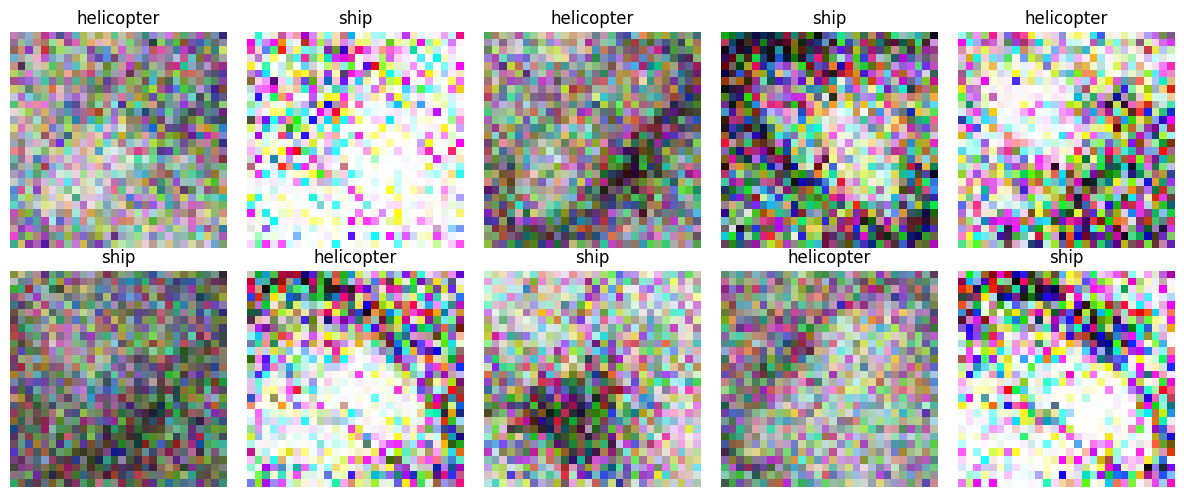

In [ ]:
# Visualisasi hasil
fig, ax = plt.subplots(
    2,
    5,
    figsize=(12,5)
)

for i, axis in enumerate(ax.flatten()):

    axis.imshow(generated_images[i])

    axis.set_title(
        encoder.inverse_transform(
            [labels[i][0]]
        )[0]
    )

    axis.axis("off")

plt.tight_layout()

plt.show()

## FID

In [ ]:
import numpy as np
import tensorflow as tf

from scipy.linalg import sqrtm

from tensorflow.keras.applications.inception_v3 import (
    InceptionV3,
    preprocess_input
)

In [ ]:
# Load inceptionV3
fid_model = InceptionV3(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(299,299,3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Fungsi resize
def resize_images(images):

    images = tf.image.resize(
        images,
        (299,299)
    )

    return images.numpy()

In [ ]:
# Generate Fake images
num_images = len(X_test)

np.random.seed(42)

fid_noise = np.random.normal(
    0,
    1,
    (num_images, LATENT_DIM)
)

fid_labels = y_test.reshape(-1, 1)

fake_images = generator.predict(
    [fid_noise, fid_labels],
    verbose=0
)

In [ ]:
# Resize Real n Fake
real_images = np.clip((X_test + 1) / 2, 0, 1)
fake_images = np.clip((fake_images + 1) / 2, 0, 1)

real_images = resize_images(real_images)
fake_images = resize_images(fake_images)

In [ ]:
# Preprocess Inception
real_images = preprocess_input(
    real_images*255
)

fake_images = preprocess_input(
    fake_images*255
)

In [ ]:
# Extract Feature
real_features = fid_model.predict(
    real_images,
    verbose=0
)

fake_features = fid_model.predict(
    fake_images,
    verbose=0)

In [ ]:
# Menghitung FID
mu1 = real_features.mean(axis=0)
mu2 = fake_features.mean(axis=0)

sigma1 = np.cov(
    real_features,
    rowvar=False
)

sigma2 = np.cov(
    fake_features,
    rowvar=False)

ssdiff = np.sum(
    (mu1-mu2)**2
)

covmean = sqrtm(sigma1 @ sigma2)

if np.iscomplexobj(covmean):
    covmean = covmean.real

fid = ssdiff + np.trace(
    sigma1 +
    sigma2 -
    2*covmean
)

print("="*40)
print(f"FID Score : {fid:.4f}")
print("="*40)

FID Score : 433.6005


In [ ]:
print(fid)

433.60047944717894


In [ ]:
# Interpretasi
if fid < 10:
    print("Excellent image quality. The generated images are highly similar to the real images.")

elif fid < 30:
    print("Good image quality. The generator successfully captures most characteristics of the real images.")

elif fid < 60:
    print("Moderate image quality. The generated images still differ from the real data distribution.")

else:
    print("Poor image quality. The generated images are still far from the distribution of the real images and require further model improvement.")

Poor image quality. The generated images are still far from the distribution of the real images and require further model improvement.


In [ ]:
print("="*60)
print("Conditional GAN Evaluation")
print("="*60)
print(f"Training Images   : {len(X_train)}")
print(f"Validation Images : {len(X_val)}")
print(f"Testing Images    : {len(X_test)}")
print(f"FID Score         : {fid:.4f}")
print("="*60)

Conditional GAN Evaluation
Training Images   : 11134
Validation Images : 1392
Testing Images    : 1392
FID Score         : 433.6005


# 3C - Modified Conditional GAN

This Modified GAN uses a convolutional Generator and Discriminator, while keeping the 3B baseline and the FID evaluation procedure unchanged.

In [ ]:
# Modified GAN settings

EPOCHS_V2 = 300
BATCH_SIZE_V2 = 64

LR_D_V2 = 0.0001
LR_G_V2 = 0.0001

print("Epochs     :", EPOCHS_V2)
print("Batch Size :", BATCH_SIZE_V2)
print("LR D       :", LR_D_V2)
print("LR G       :", LR_G_V2)

Epochs     : 300
Batch Size : 64
LR D       : 0.0001
LR G       : 0.0001


In [ ]:
# Imports for Modified Convolutional GAN

from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Embedding,
    Concatenate,
    Reshape,
    BatchNormalization,
    LeakyReLU,
    Dropout,
    Conv2D,
    Conv2DTranspose
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
# Modified Convolutional Generator

def build_generator_v2():

    noise = Input(shape=(LATENT_DIM,))
    label = Input(shape=(1,), dtype="int32")

    label_embedding = Embedding(
        NUM_CLASSES,
        50
    )(label)

    label_embedding = Flatten()(label_embedding)

    x = Concatenate()(
        [noise, label_embedding]
    )

    # 7x7 -> 14x14 -> 28x28
    x = Dense(7 * 7 * 128)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Reshape((7, 7, 128))(x)

    x = Conv2DTranspose(
        64,
        kernel_size=4,
        strides=2,
        padding="same"
    )(x)

    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(
        32,
        kernel_size=4,
        strides=2,
        padding="same"
    )(x)

    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    output = Conv2D(
        IMG_SHAPE[2],
        kernel_size=3,
        padding="same",
        activation="tanh"
    )(x)

    return Model(
        [noise, label],
        output,
        name="Generator_v2_Conv"
    )


generator_v2 = build_generator_v2()
generator_v2.summary()

Model: "Generator_v2_Conv"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 50)     │        100 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 50)        │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 150)       │          0 │ input_layer_3[0]… │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 6272)      │    947,072 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6272)      │     25,088 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 6272)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │    131,136 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │     32,800 │ leaky_re_lu_8[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 28, 28, 3) │        867 │ leaky_re_lu_9[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,137,447 (4.34 MB)

 Trainable params: 1,124,711 (4.29 MB)

 Non-trainable params: 12,736 (49.75 KB)

In [ ]:
# Modified Convolutional Discriminator

def build_discriminator_v2():

    image = Input(shape=IMG_SHAPE)
    label = Input(shape=(1,), dtype="int32")

    # Convert class label into a spatial conditioning map
    label_embedding = Embedding(
        NUM_CLASSES,
        IMG_SHAPE[0] * IMG_SHAPE[1]
    )(label)

    label_embedding = Flatten()(label_embedding)

    label_map = Reshape(
        (IMG_SHAPE[0], IMG_SHAPE[1], 1)
    )(label_embedding)

    x = Concatenate(axis=-1)(
        [image, label_map]
    )

    x = Conv2D(
        64,
        kernel_size=4,
        strides=2,
        padding="same"
    )(x)

    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Conv2D(
        128,
        kernel_size=4,
        strides=2,
        padding="same"
    )(x)

    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Flatten()(x)

    output = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        [image, label],
        output,
        name="Discriminator_v2_Conv"
    )


discriminator_v2 = build_discriminator_v2()
discriminator_v2.summary()

Model: "Discriminator_v2_Conv"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 784)    │      1,568 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 784)       │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 28, 28, 4) │          0 │ input_layer_5[0]… │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 14, 14,    │      4,160 │ concatenate_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 14, 14,    │          0 │ conv2d_95[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_10[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 7, 7, 128) │    131,200 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 7, 7, 128) │          0 │ conv2d_96[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 6272)      │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │      6,273 │ flatten_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,201 (559.38 KB)

 Trainable params: 143,201 (559.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile Modified Conditional GAN

optimizer_d_v2 = Adam(
    learning_rate=LR_D_V2,
    beta_1=0.5
)

optimizer_g_v2 = Adam(
    learning_rate=LR_G_V2,
    beta_1=0.5
)

discriminator_v2.compile(
    optimizer=optimizer_d_v2,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

discriminator_v2.trainable = False

noise = Input(shape=(LATENT_DIM,))
label = Input(shape=(1,), dtype="int32")

generated_image = generator_v2(
    [noise, label]
)

validity = discriminator_v2(
    [generated_image, label]
)

gan_v2 = Model(
    [noise, label],
    validity,
    name="Conditional_GAN_v2_Conv"
)

gan_v2.compile(
    optimizer=optimizer_g_v2,
    loss="binary_crossentropy"
)

discriminator_v2.trainable = True

In [ ]:
# Training Modified Convolutional GAN

g_losses_v2 = []
d_losses_v2 = []

for epoch in range(EPOCHS_V2):

    # ------------------------------
    # Train Discriminator
    # ------------------------------

    discriminator_v2.trainable = True

    idx = np.random.randint(
        0,
        X_train.shape[0],
        BATCH_SIZE_V2
    )

    real_images = X_train[idx]
    real_labels = y_train[idx].reshape(-1, 1)

    noise = np.random.normal(
        0,
        1,
        (BATCH_SIZE_V2, LATENT_DIM)
    )

    fake_images = generator_v2.predict(
        [noise, real_labels],
        verbose=0
    )

    real_target = np.ones(
        (BATCH_SIZE_V2, 1)
    ) * 0.9

    fake_target = np.zeros(
        (BATCH_SIZE_V2, 1)
    )

    d_loss_real = discriminator_v2.train_on_batch(
        [real_images, real_labels],
        real_target
    )

    d_loss_fake = discriminator_v2.train_on_batch(
        [fake_images, real_labels],
        fake_target
    )

    d_loss = 0.5 * np.add(
        d_loss_real,
        d_loss_fake
    )

    # ------------------------------
    # Train Generator
    # ------------------------------

    discriminator_v2.trainable = False

    noise = np.random.normal(
        0,
        1,
        (BATCH_SIZE_V2, LATENT_DIM)
    )

    sampled_labels = np.random.randint(
        0,
        NUM_CLASSES,
        BATCH_SIZE_V2
    ).reshape(-1, 1)

    valid_target = np.ones(
        (BATCH_SIZE_V2, 1)
    )

    g_loss = gan_v2.train_on_batch(
        [noise, sampled_labels],
        valid_target
    )

    discriminator_v2.trainable = True

    d_losses_v2.append(float(d_loss[0]))
    g_losses_v2.append(float(g_loss))

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{EPOCHS_V2} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {100*d_loss[1]:.2f}% | "
            f"G Loss: {g_loss:.4f}"
        )

Epoch 10/300 | D Loss: 0.6226 | D Acc: 1.36% | G Loss: 0.4785
Epoch 20/300 | D Loss: 0.5874 | D Acc: 0.67% | G Loss: 0.3593
Epoch 30/300 | D Loss: 0.5670 | D Acc: 4.21% | G Loss: 0.3371
Epoch 40/300 | D Loss: 0.5526 | D Acc: 15.19% | G Loss: 0.3358
Epoch 50/300 | D Loss: 0.5414 | D Acc: 22.19% | G Loss: 0.3331
Epoch 60/300 | D Loss: 0.5315 | D Acc: 26.84% | G Loss: 0.3320
Epoch 70/300 | D Loss: 0.5217 | D Acc: 30.16% | G Loss: 0.3399
Epoch 80/300 | D Loss: 0.5124 | D Acc: 32.65% | G Loss: 0.3656
Epoch 90/300 | D Loss: 0.5004 | D Acc: 34.58% | G Loss: 0.4166
Epoch 100/300 | D Loss: 0.4862 | D Acc: 36.13% | G Loss: 0.4893
Epoch 110/300 | D Loss: 0.4695 | D Acc: 37.39% | G Loss: 0.6632
Epoch 120/300 | D Loss: 0.4523 | D Acc: 38.45% | G Loss: 0.8805
Epoch 130/300 | D Loss: 0.4376 | D Acc: 39.34% | G Loss: 1.0140
Epoch 140/300 | D Loss: 0.4249 | D Acc: 40.10% | G Loss: 1.0969
Epoch 150/300 | D Loss: 0.4141 | D Acc: 40.76% | G Loss: 1.1681
Epoch 160/300 | D Loss: 0.4039 | D Acc: 41.34% | G L

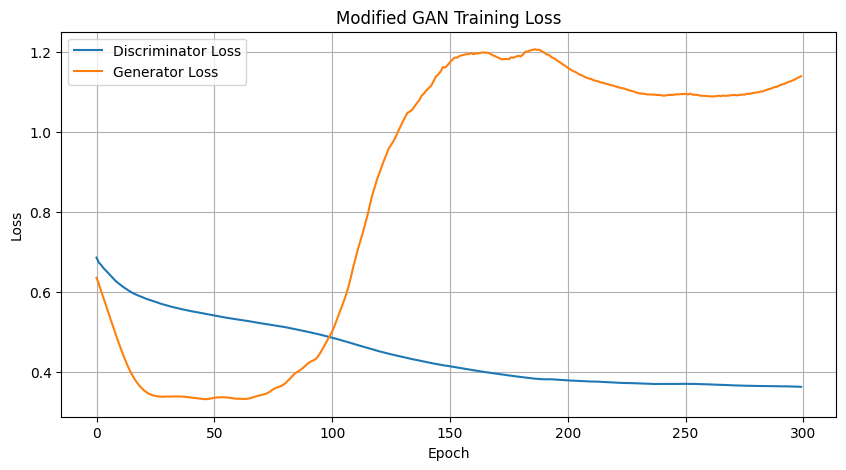

In [ ]:
# Plot Modified GAN Loss

plt.figure(figsize=(10, 5))

plt.plot(
    d_losses_v2,
    label="Discriminator Loss"
)

plt.plot(
    g_losses_v2,
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modified GAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

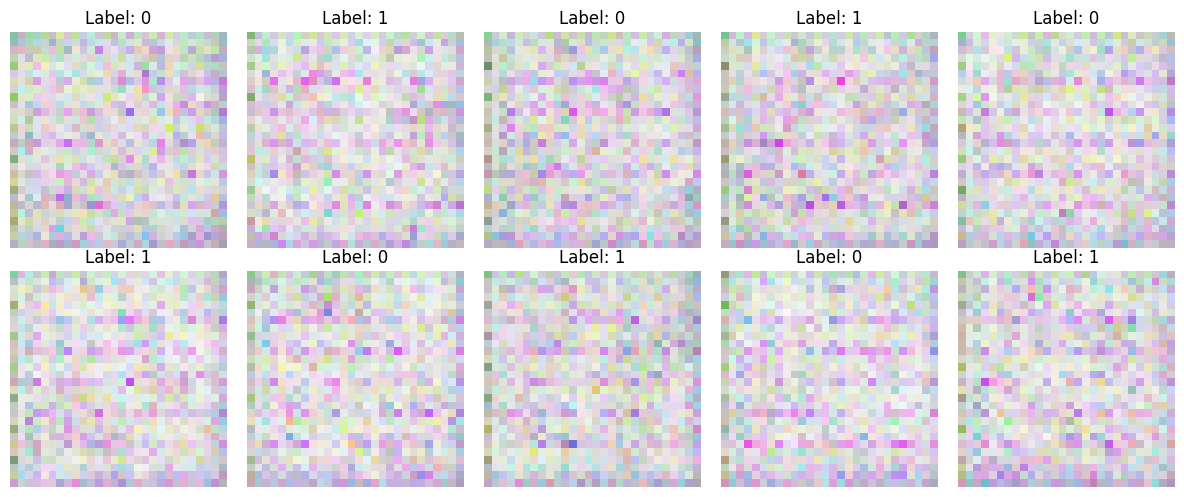

In [ ]:
# Generate images from trained Modified GAN

num_samples = 10

noise = np.random.normal(
    0,
    1,
    (num_samples, LATENT_DIM)
)

labels = np.array(
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
).reshape(-1, 1)

generated_images_v2 = generator_v2.predict(
    [noise, labels],
    verbose=0
)

generated_images_v2 = np.clip(
    (generated_images_v2 + 1) / 2,
    0,
    1
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for i, ax in enumerate(axes.flatten()):

    ax.imshow(generated_images_v2[i])
    ax.set_title(
        f"Label: {labels[i, 0]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# FID - Modified GAN
# Uses the SAME fid_noise and y_test as the 3B baseline.

fid_labels = y_test.reshape(-1, 1)

fake_images_v2 = generator_v2.predict(
    [fid_noise, fid_labels],
    verbose=0
)

real_images_fid_v2 = np.clip(
    (X_test + 1) / 2,
    0,
    1
)

fake_images_fid_v2 = np.clip(
    (fake_images_v2 + 1) / 2,
    0,
    1
)

real_images_fid_v2 = resize_images(
    real_images_fid_v2
)

fake_images_fid_v2 = resize_images(
    fake_images_fid_v2
)

real_images_fid_v2 = preprocess_input(
    real_images_fid_v2 * 255
)

fake_images_fid_v2 = preprocess_input(
    fake_images_fid_v2 * 255
)

real_features_v2 = fid_model.predict(
    real_images_fid_v2,
    verbose=0
)

fake_features_v2 = fid_model.predict(
    fake_images_fid_v2,
    verbose=0
)

mu_real_v2 = real_features_v2.mean(axis=0)
mu_fake_v2 = fake_features_v2.mean(axis=0)

sigma_real_v2 = np.cov(
    real_features_v2,
    rowvar=False
)

sigma_fake_v2 = np.cov(
    fake_features_v2,
    rowvar=False
)

covmean_v2 = sqrtm(
    sigma_real_v2 @ sigma_fake_v2
)

if np.iscomplexobj(covmean_v2):
    covmean_v2 = covmean_v2.real

fid_v2 = (
    np.sum(
        (mu_real_v2 - mu_fake_v2) ** 2
    )
    + np.trace(
        sigma_real_v2
        + sigma_fake_v2
        - 2 * covmean_v2
    )
)

print("=" * 50)
print(f"Baseline GAN (3B) : {fid:.4f}")
print(f"Modified GAN (3C): {fid_v2:.4f}")
print("=" * 50)

Baseline GAN (3B) : 433.6005
Modified GAN (3C): 409.7688


# Evaluation

Untuk melihat apakah model yang sudah dimodifikasi memberikan hasil yang lebih baik, saya membandingkannya dengan model baseline menggunakan FID (Fréchet Inception Distance).

FID digunakan untuk melihat seberapa dekat distribusi fitur dari gambar yang dihasilkan oleh GAN dengan gambar asli. Semakin kecil nilai FID, semakin dekat hasil generate dengan data asli.

Hasil yang diperoleh:

| Model | FID |
|---|---:|
| Baseline GAN (3B) | 433.6005 |
| Modified GAN (3C) | 409.7688 |

Dari hasil tersebut, FID model modified turun sebesar 23.8317 atau sekitar 5.49% dibandingkan baseline.

Jadi, berdasarkan FID, model modified menghasilkan distribusi gambar yang lebih dekat dengan data asli dibandingkan model baseline.